Returns shape: (739, 30)
First 5 tickers: ['HDFCBANK', 'ICICIBANK', 'SBIN', 'TCS', 'INFY']

Categories preview:
      Ticker             Sector
0   HDFCBANK  Banking & Finance
1  ICICIBANK  Banking & Finance
2       SBIN  Banking & Finance
3        TCS   Information Tech
4       INFY   Information Tech

Train rows: 495 Test rows: 244

Hierarchical selection summary:
  linkage=ward, use_abs_corr=False, clusters_found=10 (target=10)
  Cluster 1: size= 7 | pick=NTPC | within-cluster avg dist=0.4259
  Cluster 2: size= 3 | pick=INFY | within-cluster avg dist=0.2753
  Cluster 3: size= 3 | pick=MARUTI | within-cluster avg dist=0.3731
  Cluster 4: size= 3 | pick=HINDUNILVR | within-cluster avg dist=0.3586
  Cluster 5: size= 3 | pick=SUNPHARMA | within-cluster avg dist=0.3737
  Cluster 6: size= 3 | pick=TATASTEEL | within-cluster avg dist=0.2513
  Cluster 7: size= 3 | pick=TATACOMM | within-cluster avg dist=0.3877
  Cluster 8: size= 2 | pick=HDFCBANK | within-cluster avg dist=0.2693
  Cluster 9

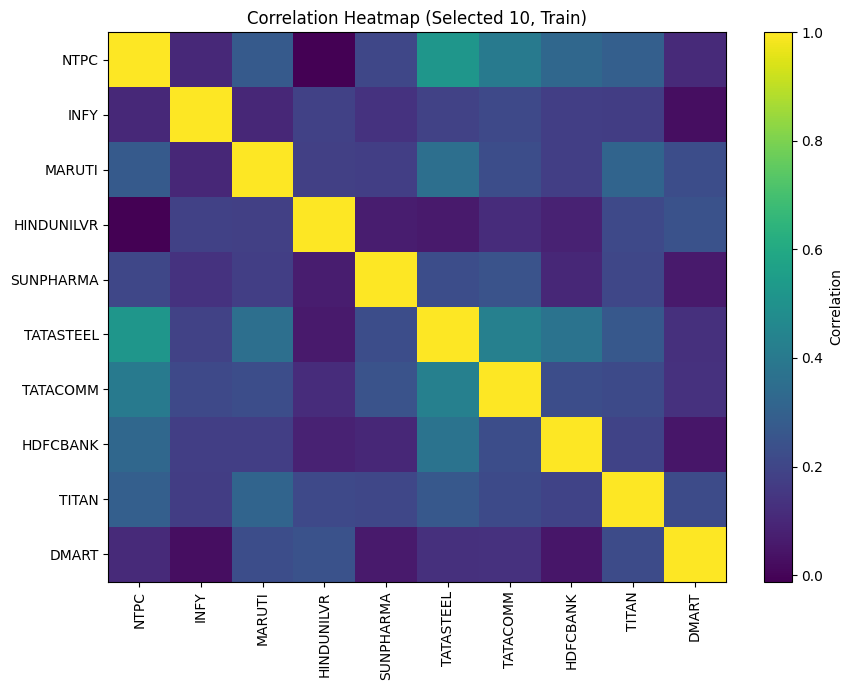

Avg |corr| among selected 10 (train): 0.1990

mu_ann shape: (10,) cov_ann shape: (10, 10)

GMV: {'w': array([0.0090948 , 0.06382251, 0.13308081, 0.25101125, 0.252653  ,
       0.00865656, 0.01909055, 0.18028827, 0.02829801, 0.05400424],
      dtype=float32), 'ret': 0.1519830971956253, 'vol': 0.10672813653945923}
MaxSharpe: {'ret': 0.2982432544231415, 'vol': 0.14031429588794708, 'sharpe': 1.6622915267944336}


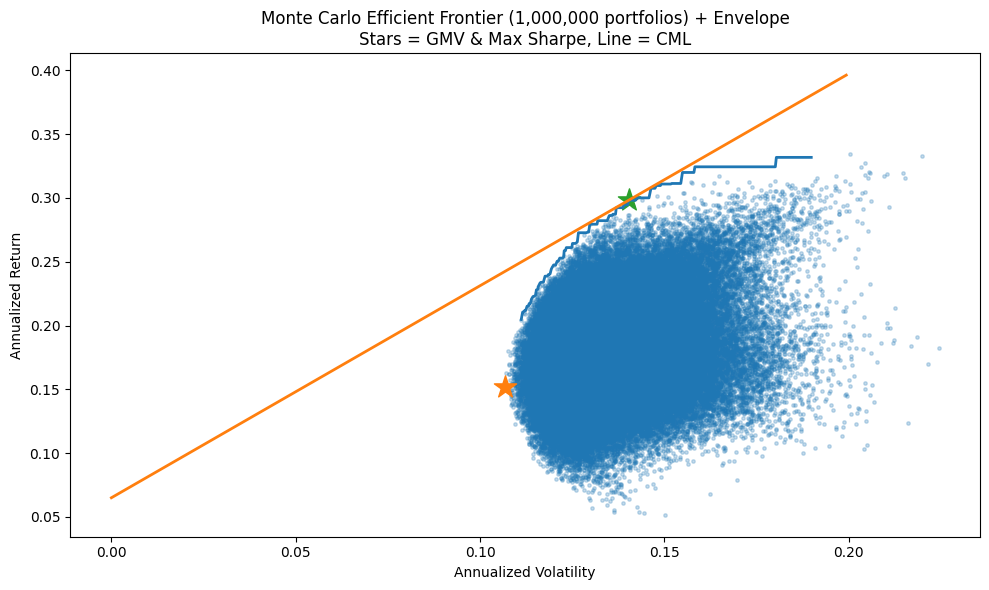


Weights (GMV vs MaxSharpe):
       Ticker  GMV_weight  MaxSharpe_weight
0        NTPC    0.009095          0.250179
1        INFY    0.063823          0.079622
2      MARUTI    0.133081          0.081305
3  HINDUNILVR    0.251011          0.008821
4   SUNPHARMA    0.252653          0.487954
5   TATASTEEL    0.008657          0.014261
6    TATACOMM    0.019091          0.011102
7    HDFCBANK    0.180288          0.018096
8       TITAN    0.028298          0.043162
9       DMART    0.054004          0.005498

Checks:
Sum GMV weights: 1.0
Sum MaxSharpe weights: 1.0000001192092896
Min weight GMV: 0.008656560443341732 Min weight MaxSharpe: 0.005498434416949749

Out-of-sample (TEST) performance summary:
     Portfolio  AnnReturn    AnnVol    Sharpe  MaxDrawdown    Calmar
0          GMV   0.022350  0.109794 -0.388454    -0.088122  0.253628
1    MaxSharpe   0.019519  0.138879 -0.327489    -0.080462  0.242580
2  EqualWeight   0.082157  0.118979  0.144200    -0.085266  0.963535


In [2]:
# ============================================================
# DA6701 Assignment 1 — Portfolio Optimization (VS Code Version)
# - Removes Colab/Drive mount
# - Replaces Greedy selection with Hierarchical Correlation-Tree selection (HRT/HRP-style)
# - Monte Carlo Efficient Frontier (1,000,000 portfolios by default)
# - GMV vs MaxSharpe weights table + correlation heatmap
# - Optional: simple out-of-sample backtest metrics on test split
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) CONFIG
# =========================
DATA_DIR = r"./"               # <-- change this to your local folder path
RETURNS_PATH = DATA_DIR + "daily_returns.xlsx"
CATS_PATH    = DATA_DIR + "stock_categories.xlsx"

# Core assignment settings
N_SELECT = 10
RF_ANNUAL = 0.065
TRADING_DAYS = 252

# Monte Carlo settings
N_PORTFOLIOS = 1_000_000
CHUNK_SIZE = 200_000          # memory-safe batching
SEED = 42

# Plot settings
SCATTER_PLOT_POINTS = 120_000  # downsample for plotting so plot stays responsive
ENVELOPE_BINS = 250           # smooth frontier line
VOL_Q_LOW, VOL_Q_HIGH = 0.002, 0.998  # trim extreme vols when drawing envelope

# Train/Test split (first ~2/3 train, last ~1/3 test)
TRAIN_FRAC = 0.67

# Dendrogram
PLOT_DENDROGRAM = False

# =========================
# 1) OPTIONAL DEPENDENCY (SciPy for hierarchical clustering)
# =========================
# If you don't have SciPy installed:
#   pip install scipy
try:
    from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
    from scipy.spatial.distance import squareform
except ImportError as e:
    raise ImportError(
        "SciPy is required for hierarchical clustering. Install it with: pip install scipy"
    ) from e


# =========================
# 2) LOAD DATA (robust loaders)
# =========================
def load_returns_xlsx(path: str) -> pd.DataFrame:
    df = pd.read_excel(path)

    # Detect a date column
    date_col = None
    for c in df.columns:
        if isinstance(c, str) and "date" in c.lower():
            date_col = c
            break

    if date_col is not None:
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.dropna(subset=[date_col]).set_index(date_col)

    # Keep only numeric columns as returns
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    ret = df[num_cols].copy()
    ret = ret.replace([np.inf, -np.inf], np.nan).dropna(how="all")

    # Heuristic: if returns look like percentages (e.g., 2.3 for 2.3%), scale down
    q99 = ret.abs().quantile(0.99).max()
    if q99 is not None and q99 > 1.5:
        ret = ret / 100.0

    # Sort index if datetime
    try:
        ret = ret.sort_index()
    except Exception:
        pass

    return ret


def load_categories_xlsx(path: str, tickers: list[str]) -> pd.DataFrame:
    cats = pd.read_excel(path)
    cats.columns = [str(c).strip() for c in cats.columns]

    best_col = None
    best_match = -1
    ticker_set = set(map(str, tickers))

    for c in cats.columns:
        col_vals = set(cats[c].astype(str).str.strip().tolist())
        match = len(col_vals.intersection(ticker_set))
        if match > best_match:
            best_match = match
            best_col = c

    sector_col = None
    for c in cats.columns:
        if isinstance(c, str) and any(k in c.lower() for k in ["sector", "category", "industry"]):
            sector_col = c
            break

    if best_col is None or best_match <= 0:
        return cats

    out = cats[[best_col] + ([sector_col] if sector_col else [])].copy()
    out = out.rename(columns={best_col: "Ticker"})
    if sector_col:
        out = out.rename(columns={sector_col: "Sector"})
    out["Ticker"] = out["Ticker"].astype(str).str.strip()
    return out


returns_all = load_returns_xlsx(RETURNS_PATH)
tickers_all = list(returns_all.columns)
cats_df = load_categories_xlsx(CATS_PATH, tickers_all)

print("Returns shape:", returns_all.shape)
print("First 5 tickers:", tickers_all[:5])
print("\nCategories preview:")
print(cats_df.head())


# =========================
# 3) TRAIN/TEST SPLIT
# =========================
n_rows = len(returns_all)
split = int(TRAIN_FRAC * n_rows)

returns_train_full = returns_all.iloc[:split].copy()
returns_test_full  = returns_all.iloc[split:].copy()

print("\nTrain rows:", returns_train_full.shape[0], "Test rows:", returns_test_full.shape[0])


# =========================
# 4) HIERARCHICAL STOCK SELECTION (HRT/HRP-style correlation tree)
# =========================
def select_stocks_hierarchical(
    returns: pd.DataFrame,
    k: int = 10,
    linkage_method: str = "ward",
    use_abs_corr: bool = False,
    plot_dendrogram: bool = False
) -> list[str]:
    """
    Select k stocks using hierarchical clustering on correlation-derived distance.

    Steps:
      1) Compute correlation on returns
      2) Convert correlation -> distance: d_ij = sqrt(0.5*(1-rho_ij))
      3) Hierarchical clustering (linkage)
      4) Cut into k clusters (maxclust)
      5) Pick 1 representative per cluster: medoid (min avg distance within cluster)

    Notes:
      - use_abs_corr=False is standard (keeps sign info).
      - use_abs_corr=True clusters by strength regardless of sign.
    """
    R = returns.dropna(how="any")
    tickers = list(R.columns)
    n_assets = len(tickers)
    if k > n_assets:
        raise ValueError(f"k={k} cannot exceed number of assets={n_assets}")

    corr = R.corr()
    if use_abs_corr:
        corr = corr.abs()
    corr = corr.clip(-1.0, 1.0)
    np.fill_diagonal(corr.values, 1.0)

    # Corr -> distance
    dist = np.sqrt(0.5 * (1.0 - corr))
    np.fill_diagonal(dist.values, 0.0)

    # Linkage expects condensed distance
    dist_condensed = squareform(dist.values, checks=False)
    Z = linkage(dist_condensed, method=linkage_method)

    if plot_dendrogram:
        plt.figure(figsize=(12, 5))
        dendrogram(Z, labels=tickers, leaf_rotation=90)
        plt.title("Hierarchical Clustering Dendrogram (Train Correlation Tree)")
        plt.tight_layout()
        plt.show()

    # Cut into k clusters (sometimes yields fewer than k; we handle that)
    labels = fcluster(Z, t=k, criterion="maxclust")

    clusters = {}
    for tkr, lab in zip(tickers, labels):
        clusters.setdefault(lab, []).append(tkr)

    # If fewer than k clusters, try slightly higher t until we reach >=k clusters (robustness)
    k_try = k
    while len(clusters) < k and k_try < n_assets:
        k_try += 1
        labels = fcluster(Z, t=k_try, criterion="maxclust")
        clusters = {}
        for tkr, lab in zip(tickers, labels):
            clusters.setdefault(lab, []).append(tkr)

    print("\nHierarchical selection summary:")
    print(f"  linkage={linkage_method}, use_abs_corr={use_abs_corr}, clusters_found={len(clusters)} (target={k})")

    # Pick medoid from each cluster
    selected = []
    cluster_items = sorted(clusters.items(), key=lambda kv: len(kv[1]), reverse=True)

    for i, (_, members) in enumerate(cluster_items, start=1):
        if len(members) == 1:
            rep = members[0]
            score = 0.0
        else:
            D = dist.loc[members, members].values
            avg_d = D.mean(axis=1)
            rep_idx = int(np.argmin(avg_d))
            rep = members[rep_idx]
            score = float(avg_d[rep_idx])

        selected.append(rep)
        print(f"  Cluster {i}: size={len(members):2d} | pick={rep} | within-cluster avg dist={score:.4f}")

    # Ensure exactly k picks
    if len(selected) > k:
        selected = selected[:k]

    # If we still have fewer than k picks (degenerate cases), fill with lowest mean |corr| to selected
    if len(selected) < k:
        remaining = [t for t in tickers if t not in selected]
        corr_abs = R.corr().abs()
        while len(selected) < k and remaining:
            scores = {cand: corr_abs.loc[cand, selected].mean() for cand in remaining}
            nxt = min(scores, key=scores.get)
            selected.append(nxt)
            remaining.remove(nxt)
            print(f"  Fallback add: {nxt} (mean |corr| to selected = {scores[nxt]:.4f})")

    return selected


# IMPORTANT: selection based on TRAIN data avoids look-ahead
selected10 = select_stocks_hierarchical(
    returns_train_full,
    k=N_SELECT,
    linkage_method="ward",
    use_abs_corr=False,
    plot_dendrogram=PLOT_DENDROGRAM
)

print("\nSelected 10:", selected10)


# =========================
# 5) SHOW SELECTED + SECTOR INFO + HEATMAP
# =========================
selected_info = pd.DataFrame({"Ticker": selected10})

if "Ticker" in cats_df.columns:
    selected_info = selected_info.merge(cats_df, on="Ticker", how="left")

print("\nSelected tickers + sector info:")
print(selected_info)

# Correlation heatmap of selected 10 (on train)
corr10 = returns_train_full[selected10].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr10.values, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(N_SELECT), selected10, rotation=90)
plt.yticks(range(N_SELECT), selected10)
plt.title("Correlation Heatmap (Selected 10, Train)")
plt.tight_layout()
plt.show()

upper = corr10.where(np.triu(np.ones_like(corr10, dtype=bool), k=1))
avg_abs_corr_10 = upper.abs().stack().mean()
print(f"Avg |corr| among selected 10 (train): {avg_abs_corr_10:.4f}")


# =========================
# 6) MPT INPUTS (mu, cov) ANNUALIZED (from TRAIN)
# =========================
R_train = returns_train_full[selected10].dropna(how="any")
mu_daily = R_train.mean().values
cov_daily = R_train.cov().values

mu_ann = mu_daily * TRADING_DAYS
cov_ann = cov_daily * TRADING_DAYS

print("\nmu_ann shape:", mu_ann.shape, "cov_ann shape:", cov_ann.shape)


# =========================
# 7) MONTE CARLO LONG-ONLY, SUM=1 (find GMV and Max Sharpe)
# =========================
def run_monte_carlo(mu_ann, cov_ann, rf=0.065, n_port=1_000_000, chunk=200_000, seed=42):
    rng = np.random.default_rng(seed)
    n_assets = len(mu_ann)

    rets = np.empty(n_port, dtype=np.float32)
    vols = np.empty(n_port, dtype=np.float32)
    sharpes = np.empty(n_port, dtype=np.float32)

    best_sharpe = -np.inf
    best_sharpe_w = None
    best_sharpe_ret = None
    best_sharpe_vol = None

    best_gmv_vol = np.inf
    best_gmv_w = None
    best_gmv_ret = None

    cov = cov_ann.astype(np.float64)
    mu = mu_ann.astype(np.float64)

    idx = 0
    while idx < n_port:
        m = min(chunk, n_port - idx)

        # Dirichlet -> nonnegative weights summing to 1
        W = rng.dirichlet(alpha=np.ones(n_assets), size=m).astype(np.float32)

        # Portfolio return (annual)
        pret = (W @ mu).astype(np.float32)

        # Portfolio variance (annual): diag(W * cov * W^T)
        pvar = np.einsum("ij,jk,ik->i", W.astype(np.float64), cov, W.astype(np.float64))
        pvol = np.sqrt(np.maximum(pvar, 1e-18)).astype(np.float32)

        psh = ((pret - rf) / np.maximum(pvol, 1e-12)).astype(np.float32)

        rets[idx:idx+m] = pret
        vols[idx:idx+m] = pvol
        sharpes[idx:idx+m] = psh

        # Update best Sharpe
        local_max = int(np.argmax(psh))
        if psh[local_max] > best_sharpe:
            best_sharpe = float(psh[local_max])
            best_sharpe_w = W[local_max].copy()
            best_sharpe_ret = float(pret[local_max])
            best_sharpe_vol = float(pvol[local_max])

        # Update GMV (min vol)
        local_min = int(np.argmin(pvol))
        if pvol[local_min] < best_gmv_vol:
            best_gmv_vol = float(pvol[local_min])
            best_gmv_w = W[local_min].copy()
            best_gmv_ret = float(pret[local_min])

        idx += m

    out = {
        "rets": rets, "vols": vols, "sharpes": sharpes,
        "gmv": {"w": best_gmv_w, "ret": best_gmv_ret, "vol": best_gmv_vol},
        "maxsharpe": {"w": best_sharpe_w, "ret": best_sharpe_ret, "vol": best_sharpe_vol, "sharpe": best_sharpe},
    }
    return out


mc = run_monte_carlo(mu_ann, cov_ann, rf=RF_ANNUAL, n_port=N_PORTFOLIOS, chunk=CHUNK_SIZE, seed=SEED)

print("\nGMV:", mc["gmv"])
print("MaxSharpe:", {k: mc["maxsharpe"][k] for k in ["ret", "vol", "sharpe"]})


# =========================
# 8) CLEAN FRONTIER LINE (Upper Envelope) + PLOTS
# =========================
def upper_envelope(vols, rets, bins=250, qlow=0.002, qhigh=0.998):
    v = vols.astype(np.float64)
    r = rets.astype(np.float64)

    vmin = np.quantile(v, qlow)
    vmax = np.quantile(v, qhigh)

    mask = (v >= vmin) & (v <= vmax) & np.isfinite(v) & np.isfinite(r)
    v = v[mask]
    r = r[mask]

    edges = np.linspace(v.min(), v.max(), bins + 1)
    idx = np.clip(np.digitize(v, edges) - 1, 0, bins - 1)

    best_r = np.full(bins, -np.inf)
    best_v = np.full(bins, np.nan)

    for i in range(bins):
        m = (idx == i)
        if np.any(m):
            j = np.argmax(r[m])
            best_r[i] = r[m][j]
            best_v[i] = v[m][j]

    ok = np.isfinite(best_v) & np.isfinite(best_r) & (best_r > -np.inf)
    best_v = best_v[ok]
    best_r = best_r[ok]

    order = np.argsort(best_v)
    best_v = best_v[order]
    best_r = best_r[order]
    best_r = np.maximum.accumulate(best_r)

    return best_v, best_r


vols = mc["vols"]
rets = mc["rets"]
sharpes = mc["sharpes"]

# Downsample for scatter plot
rng = np.random.default_rng(SEED)
plot_n = min(SCATTER_PLOT_POINTS, len(vols))
plot_idx = rng.choice(len(vols), size=plot_n, replace=False)

env_v, env_r = upper_envelope(vols, rets, bins=ENVELOPE_BINS, qlow=VOL_Q_LOW, qhigh=VOL_Q_HIGH)

plt.figure(figsize=(10, 6))
plt.scatter(vols[plot_idx], rets[plot_idx], s=6, alpha=0.25)
plt.plot(env_v, env_r, linewidth=2)

# Mark GMV and MaxSharpe (sampled points)
plt.scatter([mc["gmv"]["vol"]], [mc["gmv"]["ret"]], marker="*", s=280)
plt.scatter([mc["maxsharpe"]["vol"]], [mc["maxsharpe"]["ret"]], marker="*", s=280)

# Capital Market Line (CML) using best Sharpe slope
cml_slope = mc["maxsharpe"]["sharpe"]
cml_x = np.linspace(0.0, max(env_v.max(), mc["maxsharpe"]["vol"]) * 1.05, 200)
cml_y = RF_ANNUAL + cml_slope * cml_x
plt.plot(cml_x, cml_y, linewidth=2)

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Monte Carlo Efficient Frontier (1,000,000 portfolios) + Envelope\nStars = GMV & Max Sharpe, Line = CML")
plt.tight_layout()
plt.show()


# =========================
# 9) WEIGHTS TABLE (GMV vs MaxSharpe)
# =========================
w_gmv = mc["gmv"]["w"]
w_ms  = mc["maxsharpe"]["w"]

weights_df = pd.DataFrame({
    "Ticker": selected10,
    "GMV_weight": w_gmv,
    "MaxSharpe_weight": w_ms
})
weights_df["GMV_weight"] = weights_df["GMV_weight"].round(6)
weights_df["MaxSharpe_weight"] = weights_df["MaxSharpe_weight"].round(6)

print("\nWeights (GMV vs MaxSharpe):")
print(weights_df)

print("\nChecks:")
print("Sum GMV weights:", float(np.sum(w_gmv)))
print("Sum MaxSharpe weights:", float(np.sum(w_ms)))
print("Min weight GMV:", float(np.min(w_gmv)), "Min weight MaxSharpe:", float(np.min(w_ms)))


# =========================
# 10) OPTIONAL: SIMPLE OUT-OF-SAMPLE BACKTEST METRICS ON TEST
# =========================
def max_drawdown(returns: pd.Series) -> float:
    wealth = (1.0 + returns.fillna(0.0)).cumprod()
    peak = wealth.cummax()
    dd = wealth / peak - 1.0
    return float(dd.min())

def perf_metrics(returns: pd.Series, rf_annual: float = 0.065) -> dict:
    r = returns.dropna()
    if len(r) == 0:
        return {"AnnReturn": np.nan, "AnnVol": np.nan, "Sharpe": np.nan, "MaxDrawdown": np.nan, "Calmar": np.nan}

    ann_ret = float(r.mean() * TRADING_DAYS)
    ann_vol = float(r.std(ddof=1) * np.sqrt(TRADING_DAYS))
    sharpe = float((ann_ret - rf_annual) / ann_vol) if ann_vol > 0 else np.nan

    mdd = max_drawdown(r)
    calmar = float(ann_ret / abs(mdd)) if mdd < 0 else np.nan

    return {"AnnReturn": ann_ret, "AnnVol": ann_vol, "Sharpe": sharpe, "MaxDrawdown": mdd, "Calmar": calmar}

# Align test data to selected10 columns
R_test = returns_test_full[selected10].dropna(how="any")
if len(R_test) > 0:
    r_gmv = pd.Series(R_test.values @ w_gmv, index=R_test.index, name="GMV")
    r_ms  = pd.Series(R_test.values @ w_ms,  index=R_test.index, name="MaxSharpe")
    w_eq = np.ones(len(selected10), dtype=np.float64) / len(selected10)
    r_eq  = pd.Series(R_test.values @ w_eq,  index=R_test.index, name="EqualWeight")

    summary = pd.DataFrame([
        {"Portfolio": "GMV", **perf_metrics(r_gmv, RF_ANNUAL)},
        {"Portfolio": "MaxSharpe", **perf_metrics(r_ms, RF_ANNUAL)},
        {"Portfolio": "EqualWeight", **perf_metrics(r_eq, RF_ANNUAL)},
    ])

    print("\nOut-of-sample (TEST) performance summary:")
    print(summary)
else:
    print("\nTEST set became empty after dropna(how='any') on selected10. "
          "If your data has missing values, consider a lighter cleaning strategy.")
